<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/09_ArbolesDecisionClasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de Decisión Clasificación

## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestion de librerias
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

#Creación de modelo
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Evaluación del modelo
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = '02_GermanCredit_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
# Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/02_GermanCredit_Prep.csv
dataset descargado exitosamente a: datasets/02_GermanCredit_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [6]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
#sys.path.append(UTILS_PATH)

## Importar Funciones externas
#from funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [7]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv(local_dataset_path)

In [8]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_account_status   1138 non-null   object
 1   loan_duration_mo          1138 non-null   int64 
 2   credit_history            1138 non-null   object
 3   purpose                   1138 non-null   object
 4   loan_amount               1138 non-null   int64 
 5   savings_account_balance   1138 non-null   object
 6   time_employed_yrs         1138 non-null   object
 7   payment_pcnt_income       1138 non-null   int64 
 8   gender_status             1138 non-null   object
 9   other_signators           1138 non-null   object
 10  time_in_residence         1138 non-null   int64 
 11  property                  1138 non-null   object
 12  age_yrs                   1138 non-null   int64 
 13  other_credit_outstanding  1138 non-null   object
 14  home_ownership          

## 4. Visualización de datos

### Variables de entrada

In [9]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,checking_account_status,credit_history,purpose,savings_account_balance,time_employed_yrs,gender_status,other_signators,property,other_credit_outstanding,home_ownership,job_category,telephone,foreign_worker
0,< 0 DM,critical account - other non-bank loans,car,< 100 DM,1 - 4 years,female-divorced/separated/married,co-applicant,real estate,none,own,skilled,none,yes
1,< 0 DM,current loans paid,car,< 100 DM,1 - 4 years,male-married/widowed,none,real estate,none,own,unskilled-resident,none,yes


In [10]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()

d[numCols].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,bad_credit
0,12,3499,3,2,29,2,1,1
1,12,1168,4,3,27,1,1,0


In [11]:
##Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [12]:
##Visualización de variables numéricas
#multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [13]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('bad_credit')

### Variable de salida

In [14]:
# Distriución de la variable de salida

d.groupby('bad_credit').bad_credit.count().sort_values(ascending=False)

,bad_credit
bad_credit,
0,569
1,569


In [15]:
##Visualización de la variable de salida
#multiple_plot(1, d , None, 'bad_credit', 'countplot', 'Gráfica de frecuencia de bad Credit',0)

## 5. Transformación de datos

### Creación de variables Dummies

In [16]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 46 columns):
 #   Column                                                  Non-Null Count  Dtype
---  ------                                                  --------------  -----
 0   loan_duration_mo                                        1138 non-null   int64
 1   loan_amount                                             1138 non-null   int64
 2   payment_pcnt_income                                     1138 non-null   int64
 3   time_in_residence                                       1138 non-null   int64
 4   age_yrs                                                 1138 non-null   int64
 5   number_loans                                            1138 non-null   int64
 6   dependents                                              1138 non-null   int64
 7   bad_credit                                              1138 non-null   int64
 8   checking_account_status_< 0 DM                          11

## 6. Creación del modelo

### Dividir el conjunto de datos

In [17]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d.drop(columns ='bad_credit')
y = d['bad_credit']

In [18]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

### Escalar Variables

In [19]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

print(num_vars)

['loan_duration_mo', 'loan_amount', 'payment_pcnt_income', 'time_in_residence', 'age_yrs', 'number_loans', 'dependents']


In [20]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
9,0.0294,0.1319,0.3333,0.3333,0.1667,0.0000,0.0000
798,0.5588,0.5622,0.3333,1.0000,0.4630,0.0000,1.0000


### Creación del modelos

- **criterion** (default=”gini”): Función para medir la calidad de la partición: “gini”, “entropy”, “log_loss”.
    - Gini es más rápido de calcular que la entropía, tiende a favorecer la partición de nodos que contienen clases mayoritarias en el conjunto de datos.
    - La entropía tiende a favorecer la creación de árboles más equilibrados y puede ser más útil cuando se tienen múltiples clases con distribuciones más uniformes.
Aunque ligeramente más costosa computacionalmente que Gini,
- **max_depth** (default=None): maxima profundidad del árbol
- **min_samples_split**(default=2): Mínimo de ejemplos para separar un nodo interno
- **min_samples_leaf**(default=1): Mínimo numero de ejemplos requeridos en un nodo hoja
- **ccp_alpha**: Parámetro de complejidad usado para el  Minimal Cost-Complexity de poda. Es un algoritmo que se usa para podar un árbol para evitar el over-fitting. Un ccp_alpha bajo el Árbol es más grande, riesgo de sobreajuste.


In [21]:
# Creación del modelo
# ------------------------------------------------------------------------------
modelDtree = DecisionTreeClassifier(
            max_depth         = 5,
            criterion         = 'gini',
            random_state      = 123
          )

# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelDtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=123)

Profundidad del árbol: 5
Número de nodos terminales: 25


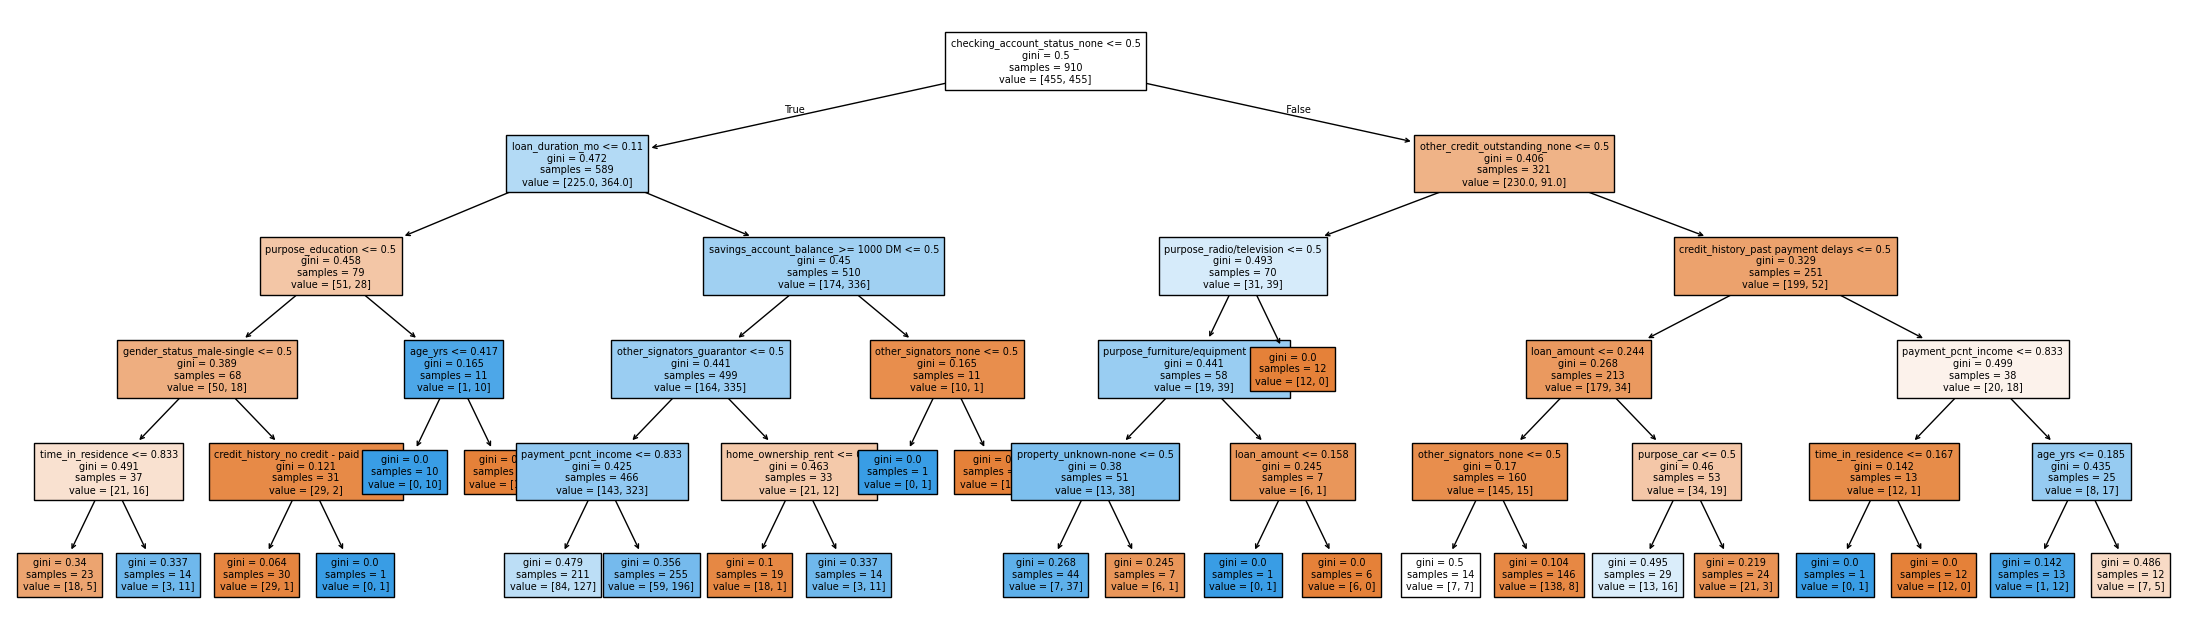

In [22]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------


fig, ax = plt.subplots(figsize=(28, 8))


print(f"Profundidad del árbol: {modelDtree.get_depth()}")
print(f"Número de nodos terminales: {modelDtree.get_n_leaves()}")

plot = plot_tree(
    decision_tree=modelDtree,
    feature_names=X.columns,
    filled=True,
    impurity=True,
    fontsize=7,
    ax=ax
)



In [23]:
y_pred = modelDtree.predict(X_test)

##### Evaluación del modelo

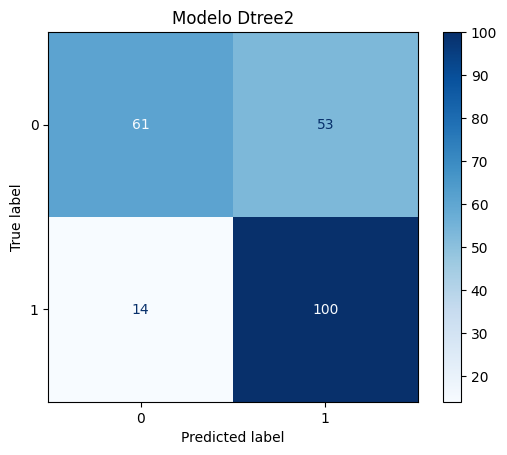

              precision    recall  f1-score   support

           0       0.81      0.54      0.65       114
           1       0.65      0.88      0.75       114

    accuracy                           0.71       228
   macro avg       0.73      0.71      0.70       228
weighted avg       0.73      0.71      0.70       228



In [24]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title('Modelo Dtree2')

# Mostrar la figura
plt.show()

# Mostrar el informe de clasificación
print(classification_report(y_test, y_pred))

## 7. Afinando el modelo (tuning)

In [25]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = d.drop(columns ='bad_credit')
y = d['bad_credit']

# la validación cruzada se realiza sobre todo el dataset
X_Completo = X
y_Completo = y


In [26]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

X_Completo[num_vars].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
0,0.1176,0.2356,0.6667,0.3333,0.1667,0.3333,0.0000
1,0.1176,0.0619,1.0000,0.6667,0.1296,0.0000,0.0000


### Podado del árbol (pruning)

###  ***ccp_alpha*** en la complejidad de Árboles de Decisión

Esta tabla resume cómo distintos valores de ccp_alpha afectan la complejidad y profundidad del árbol de decisión, así como el riesgo de overfitting o underfitting asociado a cada nivel de regularización.


| ccp_alpha | Complejidad del árbol | Profundidad típica | Riesgo principal     |
|----------|----------------------|--------------------|----------------------|
| Bajo (≈0) | Muy alta             | Muy profunda       | Overfitting          |
| Medio     | Balanceada           | Moderada           | Buen trade-off       |
| Alto      | Baja                 | Poco profunda      | Underfitting         |

In [27]:
# Post pruning (const complexity pruning) por validación cruzada

# El árbol se crece al máximo posible antes de aplicar el pruning
modelTreeC= DecisionTreeClassifier(
                            max_depth         = None,
                            #min_samples_split = 2,
                            #min_samples_leaf  = 1,
                            random_state      = 123
                       )


# Definir los parámetros para la búsqueda en la cuadrícula
parameters = {'ccp_alpha': np.logspace(-6, 2, 9)} # Valores entre 0.000001 y 100 en una escala logarítmica


# Definimos las metricas sobre las que queremos evaluar
metricas = 'f1'

# definicion de la variable con el número de pliegues
CV = 10

# Búsqueda por validación cruzada
grid_TreeC = GridSearchCV(
        estimator =  modelTreeC,
        param_grid = parameters,
        scoring    = metricas,
        cv         = CV,
        refit      = True,
        return_train_score = True
      )

grid_TreeC.fit(X_Completo, y_Completo)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=123),
             param_grid={'ccp_alpha': array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
       1.e+02])},
             return_train_score=True, scoring='f1')

In [28]:
#pd.set_option('display.float_format', lambda x: '%.8f' % x)

# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid_TreeC.cv_results_)
resultados.filter(regex = '(param*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(10)

,param_ccp_alpha,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.0000,0.8505,0.0390,1.0000,0.0000
1,0.0000,0.8505,0.0390,1.0000,0.0000
2,0.0001,0.8505,0.0390,1.0000,0.0000
3,0.0010,0.8351,0.0417,0.9860,0.0028
4,0.0100,0.7243,0.0212,0.7251,0.0027
5,0.1000,0.0663,0.1988,0.0667,0.2001
6,1.0000,0.0663,0.1988,0.0667,0.2001
7,10.0000,0.0663,0.1988,0.0667,0.2001
8,100.0000,0.0663,0.1988,0.0667,0.2001


In [29]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)

resultados['diff_test_train'] = abs(resultados['mean_test_score'] - resultados['mean_train_score'])
resultados.filter(regex = '(param*|mean_t|std_t|diff_test_train)') \
    .drop(columns = 'params') \
    .sort_values(by=['diff_test_train', 'param_ccp_alpha'], ascending = [True, False]) \
    .head(10)

,param_ccp_alpha,mean_test_score,std_test_score,mean_train_score,std_train_score,diff_test_train
8,100.0000,0.0663,0.1988,0.0667,0.2001,0.0004
7,10.0000,0.0663,0.1988,0.0667,0.2001,0.0004
6,1.0000,0.0663,0.1988,0.0667,0.2001,0.0004
5,0.1000,0.0663,0.1988,0.0667,0.2001,0.0004
4,0.0100,0.7243,0.0212,0.7251,0.0027,0.0008
2,0.0001,0.8505,0.0390,1.0000,0.0000,0.1495
1,0.0000,0.8505,0.0390,1.0000,0.0000,0.1495
0,0.0000,0.8505,0.0390,1.0000,0.0000,0.1495
3,0.0010,0.8351,0.0417,0.9860,0.0028,0.1509


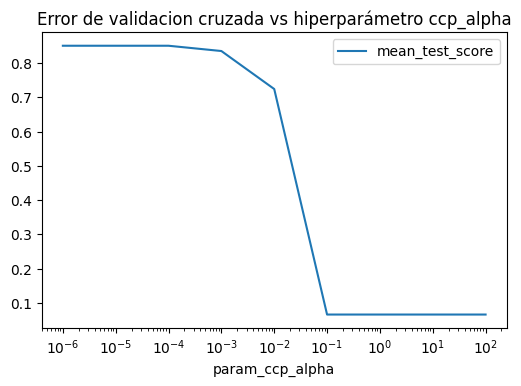

In [30]:
fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid_TreeC.cv_results_)


# Variacion de ccp_alpha
ax.set_xscale('log')
#scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score',  ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");

In [31]:
# Mejor valor ccp_alpha encontrado
# ------------------------------------------------------------------------------
#grid_TreeC.best_params_

In [32]:
# Creación del modelo
# ------------------------------------------------------------------------------
modelTreeC.set_params(
            ccp_alpha         = 0.0100,
            random_state      = 123
          )

# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelDtree.fit(X_Completo, y_Completo)

DecisionTreeClassifier(max_depth=5, random_state=123)

In [33]:
print(f"Profundidad del árbol: {modelDtree.get_depth()}")
print(f"Número de nodos terminales: {modelDtree.get_n_leaves()}")

Profundidad del árbol: 5
Número de nodos terminales: 26


### Guardar modelo

In [34]:
#Se guarda el modelo de Árbol de decisión

MODEL_FILE_NAME = 'DTreeC_CV.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)

joblib.dump(modelDtree,  local_model_path)

['modelos/clasificacion/DTreeC_CV.pkl']

## 7. Importancia de predictores

### Importancia por pureza de nodos

In [35]:
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores = pd.DataFrame(
                            {'predictor': X.columns,
                             'importancia': modelDtree.feature_importances_}
                            )
importancia_predictores.sort_values('importancia', ascending=False).head(10)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
9,checking_account_status_none,0.2726
0,loan_duration_mo,0.1251
36,other_credit_outstanding_none,0.0855
3,time_in_residence,0.0753
1,loan_amount,0.0709
2,payment_pcnt_income,0.0571
22,savings_account_balance_>= 1000 DM,0.0473
42,job_category_unskilled-resident,0.0426
13,credit_history_past payment delays,0.0423
15,purpose_education,0.0351


#### Referencias


- Áboles de decisión
    - https://www.aprendemachinelearning.com/arbol-de-decision-en-python-clasificacion-y-prediccion/
    - https://www.cienciadedatos.net/documentos/py07_arboles_decision_python.html